### This notebook is an example of how to use the MSSA method to separate different oscillations of netcdf file 3D (lat, lon, time) 

In [1]:
import sys 

sys.path.append('/Users/azr/Desktop/MSSA/scripts/')
import preprocessing_embedding as pre
import mssa_PC_RC as mssa
import plotting_mssa as pltmssa
import tools_MSSA as tmssa
import monte_carlo as mc 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Example with only one variable (e.g. sst from ERA5 1950-2024)

VARIABLES = {"sst": {
        "path": "/Users/azr/Desktop/PhD/datasets/ERA5/yearly_sst_FROM_ERA5_1950_2024.nc", # change with your path
        "field": "sst",
        "title": "SST",
        "unit": "Kelvin",
        "fix_grid": False}}


saving_path = "/Users/azr/Desktop/MSSA/figures" # where the figures will be saved


# Needed in the case of more than one variables, with different spatial grids
# Here I used the less refined grid as target one. 

#ds_target_grid = xr.open_dataset("/Users/azr/Desktop/PhD/datasets/OHC_Audrey/yearly_IAP_ohc_0_300m.nc")
#ds_target_grid = ds_target_grid.assign_coords(lon=((ds_target_grid.lon + 180) % 360) - 180).sortby("lon")
#ds_target_grid = ds_target_grid.isel(time=0).drop_vars([v for v in ds_target_grid.data_vars])
#if ds_target_grid.lat.values[0] < ds_target_grid.lat.values[-1]:
#        ds_target_grid = ds_target_grid.sortby("lat", ascending=False)
#if ds_target_grid.lon.values[0] > ds_target_grid.lon.values[-1]:
#    ds_target_grid = ds_target_grid.sortby("lon")

sst
Loading: sst


/opt/anaconda3/envs/env2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applying SST mask to all variables...
Computing EOF for: sst
% variance (first 50 modes): 98.59063720703125


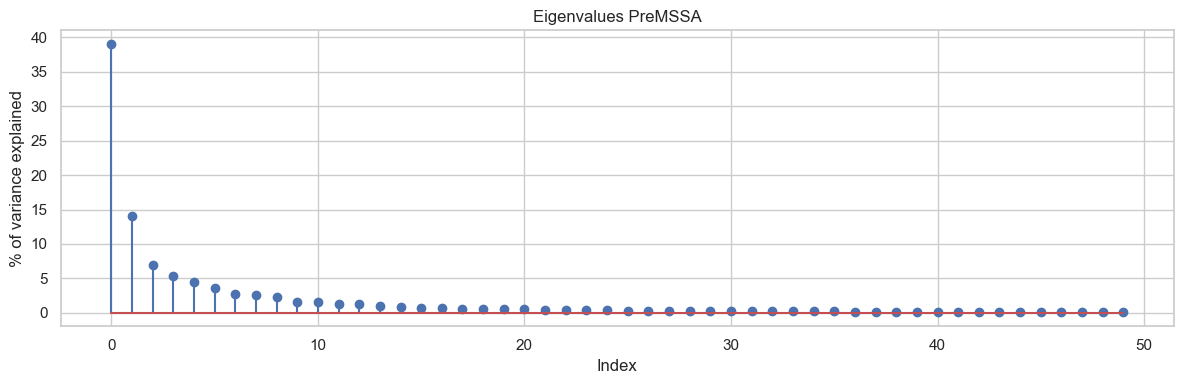

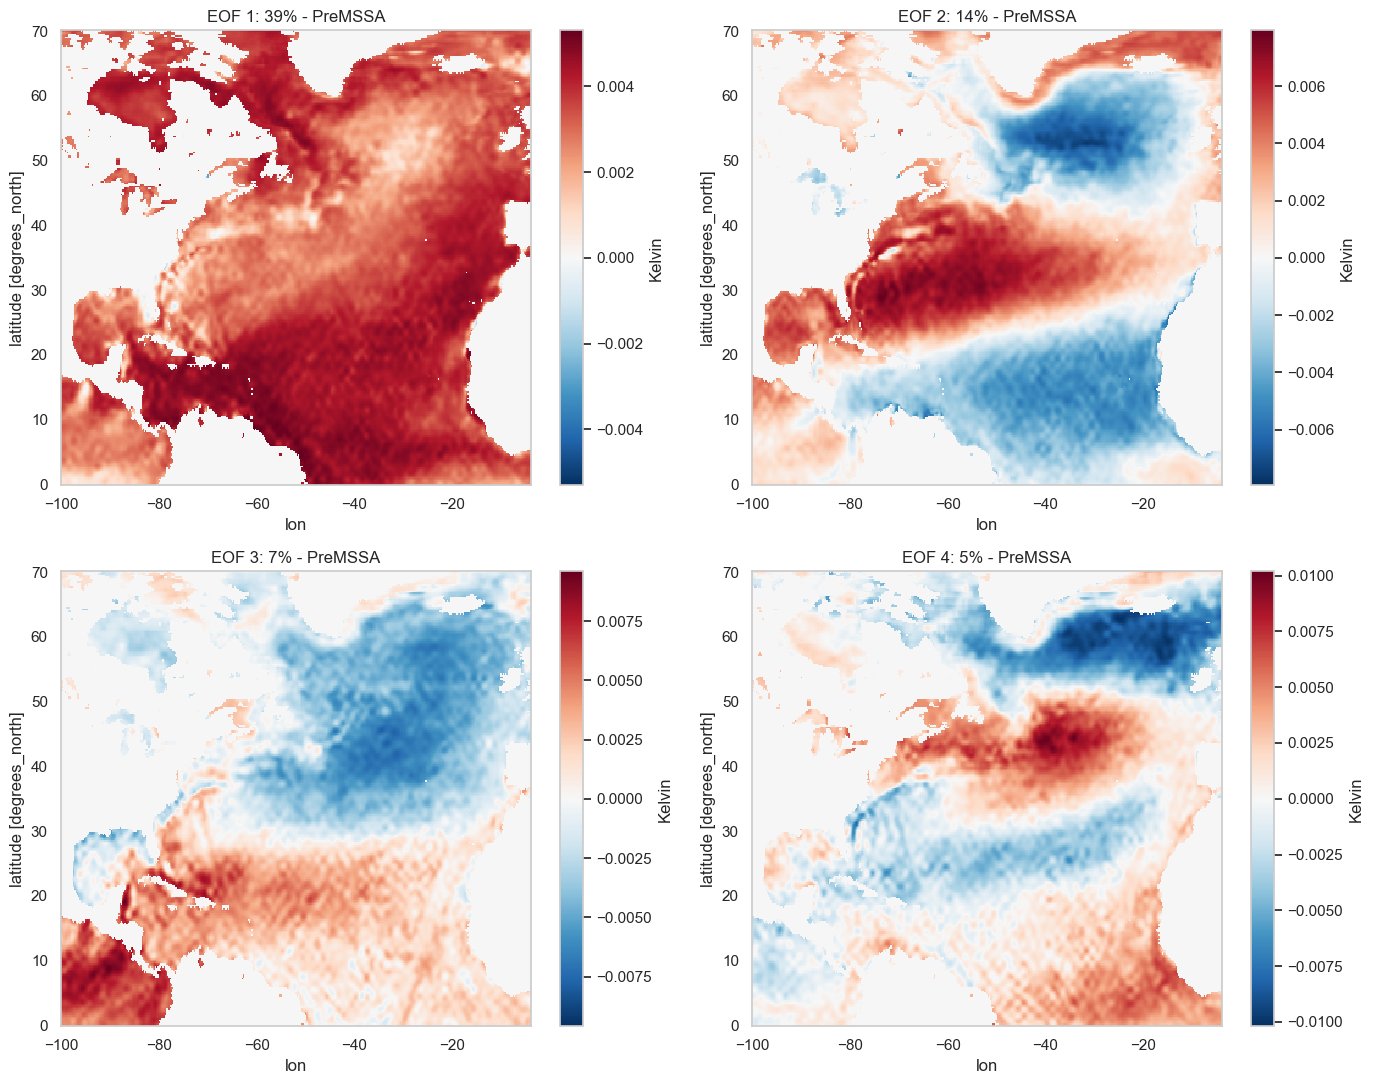

Common time length: 71
All variables share the exact same grid.


In [3]:
# --- Definition of the different parameters ---

# Latitude and longitude boundaries
# For North Atlantic
NL, SL = 70.0, 0.0
WL, EL = -100, -4

# Set the time boundaries
start_year = 1950 
end_year = 2020

# Number of EOFs to keep after the preprocessing step
D_eof = 50

# To name the figures 
names = list(VARIABLES.keys())
sep = "_"
varset_name = sep.join(VARIABLES.keys()) 
print(varset_name)

# --- Normalization and titles for plots ---
var_norm = []
var_std = []
titles = []
for name, cfg in VARIABLES.items():
    print("Loading:", name)
    da = pre.load_variable(cfg, NL, SL, WL, EL, start_year, end_year)
    #da = load_variable(cfg, NL, SL, WL, EL, start_year, end_year, ds_target_grid)

    # Drop unwanted dimensions (e.g., pressure_level)
    extra_dims = [d for d in da.dims if d not in ["time", "lat", "lon"]]
    if extra_dims:
        print(f"Dropping extra dims: {extra_dims}")
    da = da.squeeze(extra_dims, drop=True)

    da_norm, std = pre.prepare_anomalies(da)

    var_norm.append(da_norm)
    var_std.append(std)
    titles.append(cfg.get("title"))


# --- OPTIONAL: Creation of SST (first variable here) reference mask (acting like a land-sea mask) ---
sst_mask = np.isnan(var_norm[0]).any(dim="time")
print("Applying SST mask to all variables...")
for i in range(len(var_norm)):
    var_norm[i] = var_norm[i].where(~sst_mask)
    var_norm[i] = var_norm[i].fillna(0) # Fill NaNs for EOF solver stability


# --- EOF computation (preliminary step before MSSA) ---
pcs_list = []
eofs_maps = []
expvar_list = []

for i, varname in enumerate(names):
    print("Computing EOF for:", varname)

    pcs, eofs, expvar = pre.compute_preEOF(var_norm[i], D_eof)
    cfg = VARIABLES[name]
    
    pcs_list.append(pcs)
    eofs_maps.append(eofs)
    expvar_list.append(expvar)

    print(f"% variance (first {D_eof} modes):", float(expvar.sum()))

    # --- Plotting the EOF spectrum ---
    pltmssa.plotting_eigenvalues(expvar,"PreMSSA",varset_name,varname,saving_path=saving_path)

    # --- Plotting the EOF maps ---
    pltmssa.plotting_EOFmaps(eofs,expvar,cfg,"PreMSSA",varset_name,varname,saving_path=saving_path)


# --- Final check to see if the grids are aligned for all variables --- 
time_lengths = [da.shape[0] for da in var_norm]
if not all(t == time_lengths[0] for t in time_lengths):
    raise Exception("Timeseries lengths do not match!")

N = time_lengths[0]
print("Common time length:", time_lengths[0])

pre.check_common_grid([da for da in var_norm])

In [4]:
# --- Creation of a datetime index ---

start_date = f'{start_year}-01'
n_years = N
time_axis = pd.date_range(start=start_date, periods=n_years, freq='YS')

In [5]:
# --- Set MSSA parameters ---

# Use the pre-PCA outputs as inputs for the MSSA 
X = np.hstack(pcs_list)
print("X.shape is", X.shape) # shape is (N,D_eof*n_vars) (or D_eof???) 

# Choice of the embedding window (in years for yearly data and in months for monthly data)
M = 30 

X.shape is (71, 50)


In [6]:
# --- Embedding the dataset ---

X_embedded = pre.embedding(X,M)
print("X_embedded.shape is", X_embedded.shape) # should be (N-M+1,D_eof*M)

X_embedded.shape is (42, 1500)


In [7]:
# --- MSSA computation and outputs ---

# MSSA
eigvect,eigval,expvar_mssa,PCs,U_mssa = mssa.mssa_workflow(X_embedded,X,M,type='ECON')

# Dominant frequency (for each PC)
freq_dom, period_dom = mssa.dominant_frequency(PCs)

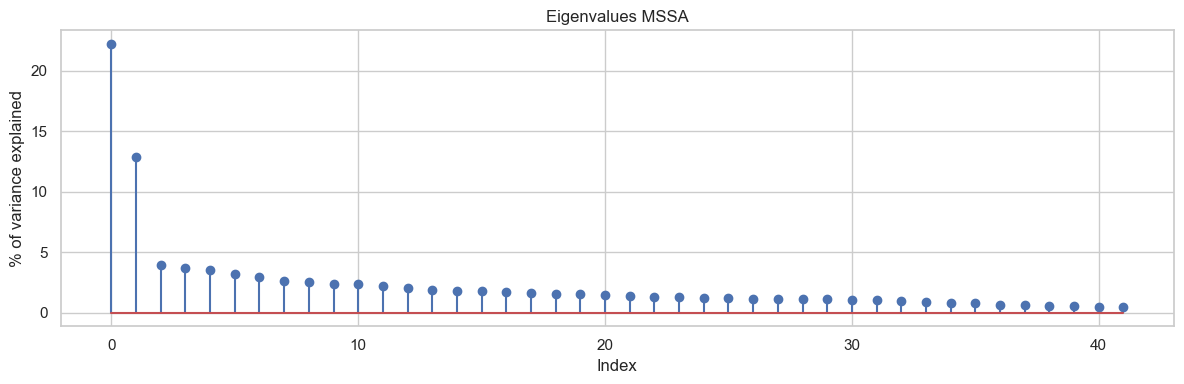

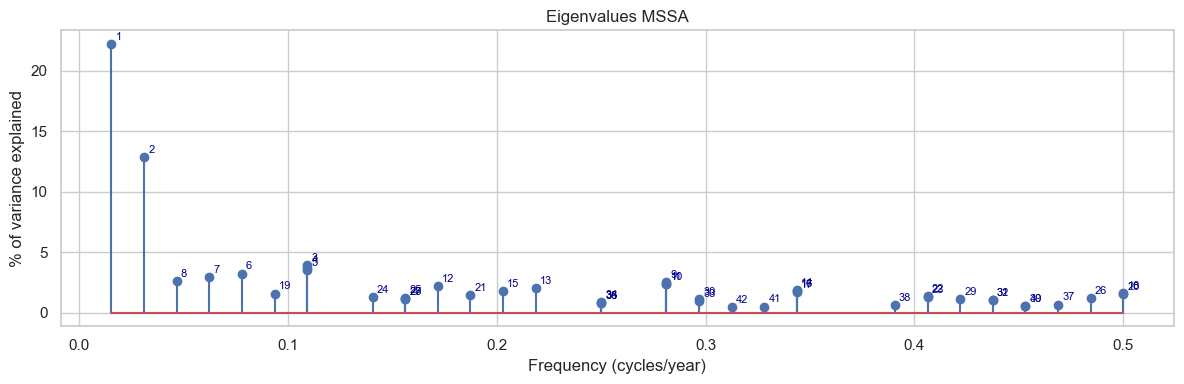

In [8]:
# --- Plotting the eigenvalues spectrums (index and frequency) ---

pltmssa.plotting_eigenvalues(expvar_mssa,"MSSA",varset_name,varname,saving_path=saving_path,freq=None)
pltmssa.plotting_eigenvalues(expvar_mssa,"MSSA",varset_name,varname,saving_path=saving_path,freq=freq_dom)

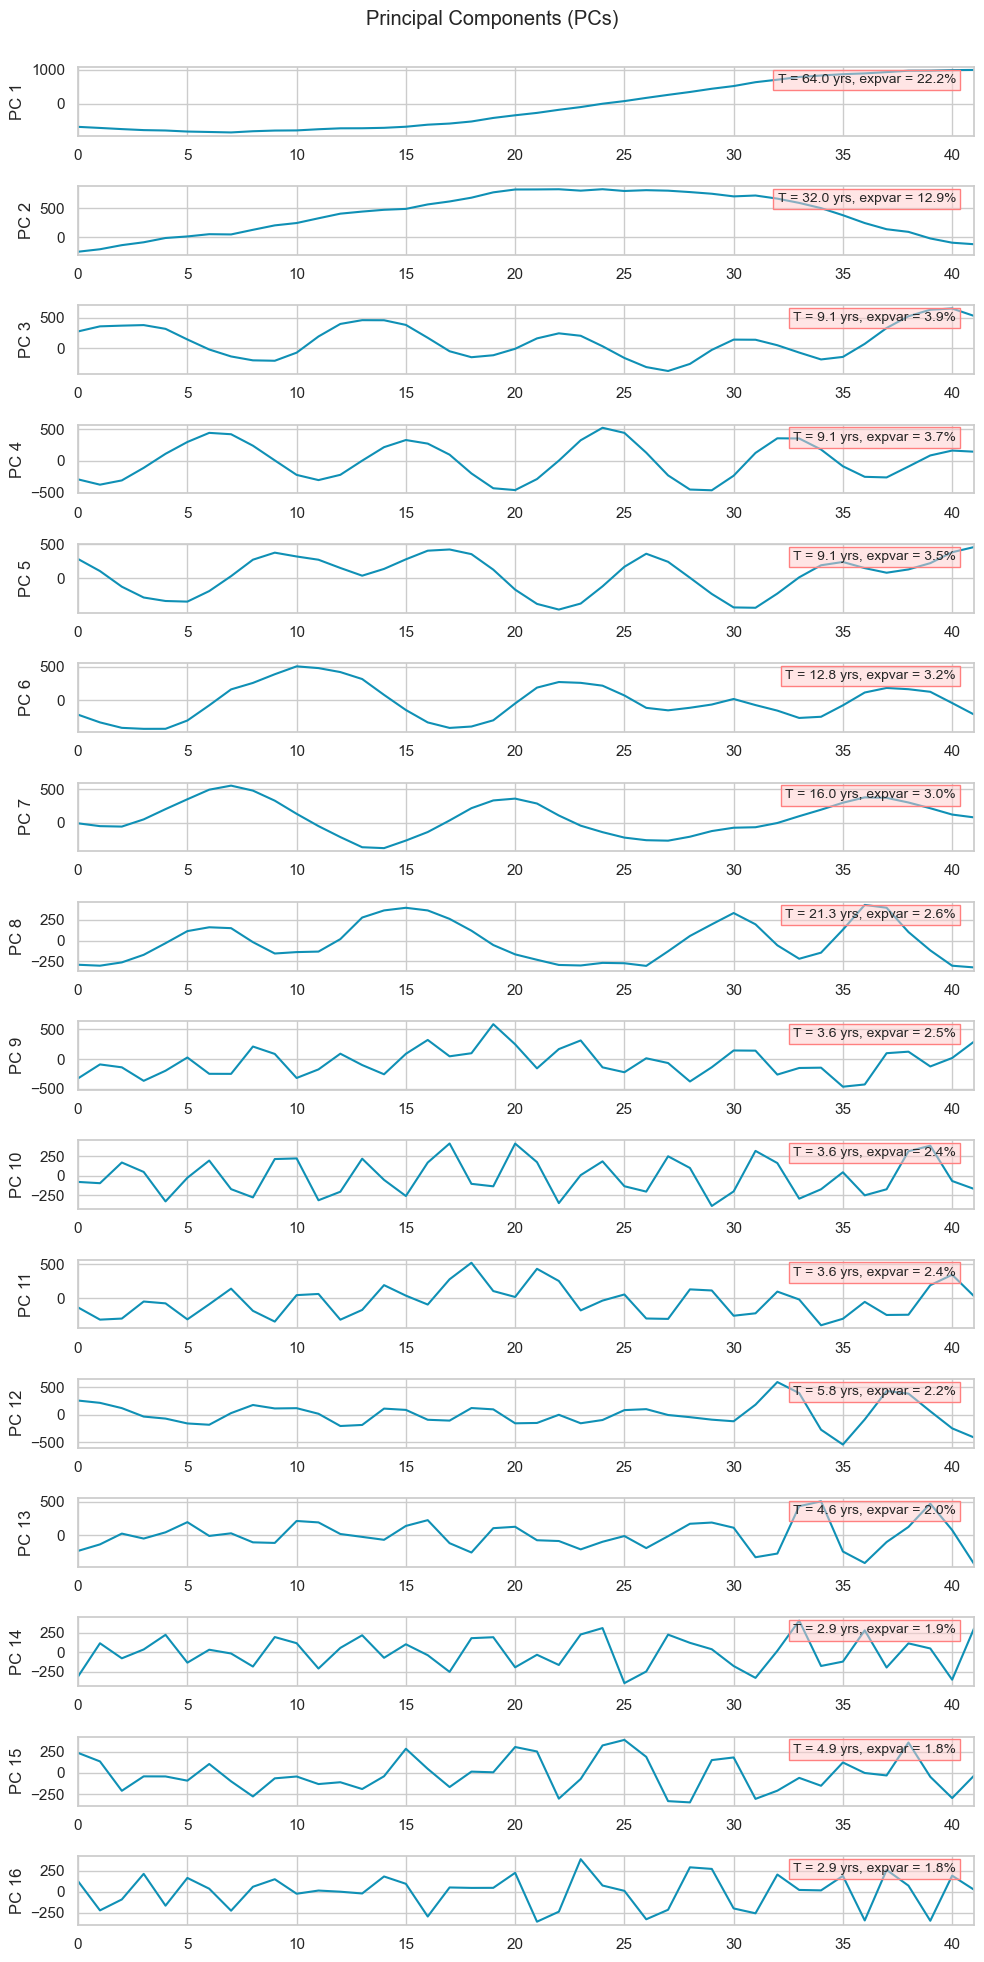

In [9]:
# --- Plotting the PCs ---

pltmssa.plotting_PCs(PCs,freq_dom,expvar_mssa,M,varset_name,saving_path=saving_path)

In [10]:
# --- Calculation of the RCs --- 

D_mssa = X.shape[1] # number total of MSSA channels, equivalent to n_vars * D_eof
n_vars = len(VARIABLES.keys())
n_lim = min(N-M+1,D_mssa*M)
n = np.arange(n_lim) # number of MSSA modes 

RCs = mssa.reconstruct_components(eigvect,PCs,n,M,N,D_mssa)
print("RCs.shape is", RCs.shape)

RCs.shape is (71, 50, 42)


In [11]:
# --- Separation of the RCs by variables ---

RCs_by_var = mssa.separate_RCs_by_var(RCs,n_vars,D_eof)
print(np.shape(RCs_by_var))

(1, 71, 50, 42)


In [12]:
# --- Turn the RCs back in the lat/lon domain basis by groups (single, pairs, triples...)

VAR1_RC1, VAR1_RC1_ts, VAR1_RC1_map = mssa.reconstruct_RCs_group(
    RCs_by_var[0], # first variable, if another variable is wanted change the indice
    eofs_maps[0],  # corresponds also to first variable
    var_std[0],    # corresponds also to first variable
    [1])    # means RC1 (1-based indexing) --> to adapt, for example if we want RC1+RC2 use [1,2]

In [13]:
# --- This is used for the phase definition, when we have an oscillation (not for a trend) ---
# This has to be modified in order to be more efficient and detect better the oscillations
# also need to add an argument "trend" or "oscillation" in the RC plotting function
# to be able to adapt the phases manually for a trend

RCs_var1 = RCs_by_var[0]
RCs_var1_T = np.transpose(RCs_var1, (1, 0, 2))

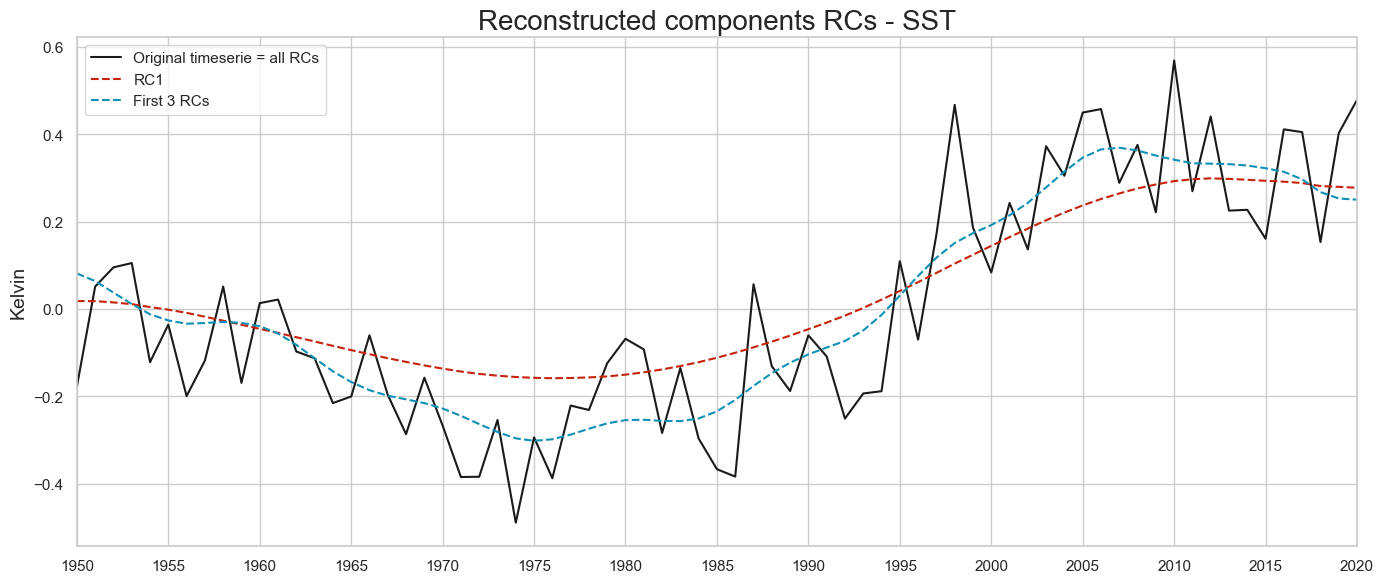

In [16]:
# --- Plotting the RCs timeseries ---

units_list = [v["unit"] for v in VARIABLES.values()]
var_names  = [v["title"] for v in VARIABLES.values()]

# Example 1 : Plot the original timeserie, the first RC and the sum of RC1+RC2+RC3
groups1 = [
    ("Original timeserie = all RCs", None),
    ("RC1", [1]),
    ("First 3 RCs", [1, 2, 3]),
]

pltmssa.plot_RCs_by_variable(
    RCs_by_var, eofs_maps, var_std, var_names, units_list,
    time_axis, groups1,
    saving_path=saving_path,
    title="first_3"
)

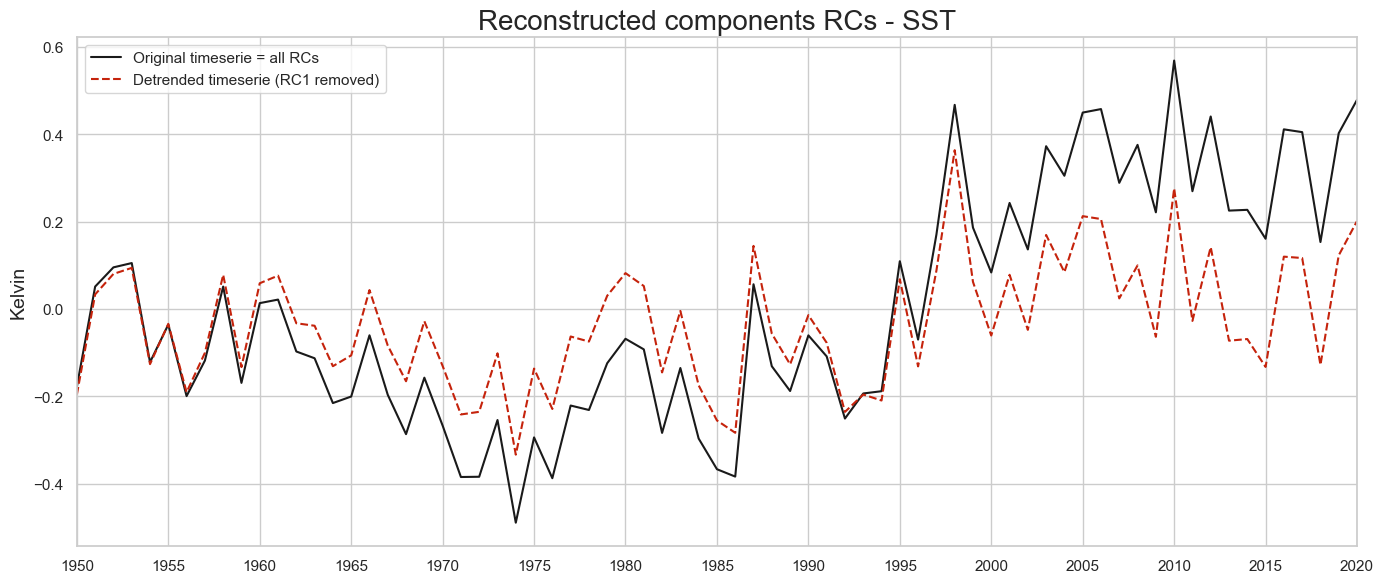

In [17]:
# Example 2 : Plot the original timeserie and the detrended one 

groups2 = [
    ("Original timeserie = all RCs", None),
    ("Detrended timeserie (RC1 removed)", [i for i in range(2,np.shape(RCs_by_var)[3]+1)]),
    ]

pltmssa.plot_RCs_by_variable(
    RCs_by_var, eofs_maps, var_std, var_names, units_list,
    time_axis, groups2,
    saving_path=saving_path,
    title="all_RCs_vs_detrended"
)

/Users/azr/Desktop/MSSA/scripts/plotting_mssa.py:306: RuntimeWarning: Mean of empty slice
  fields = [np.nanmean(VAR[:,:,idx], axis=2) for idx in phases]


global max: 1.5011282706021778


/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value enco

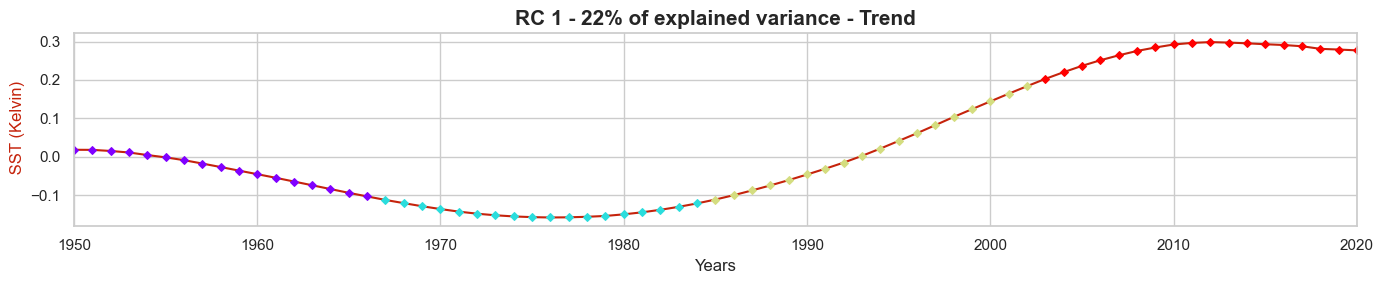

/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/env2/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value enco

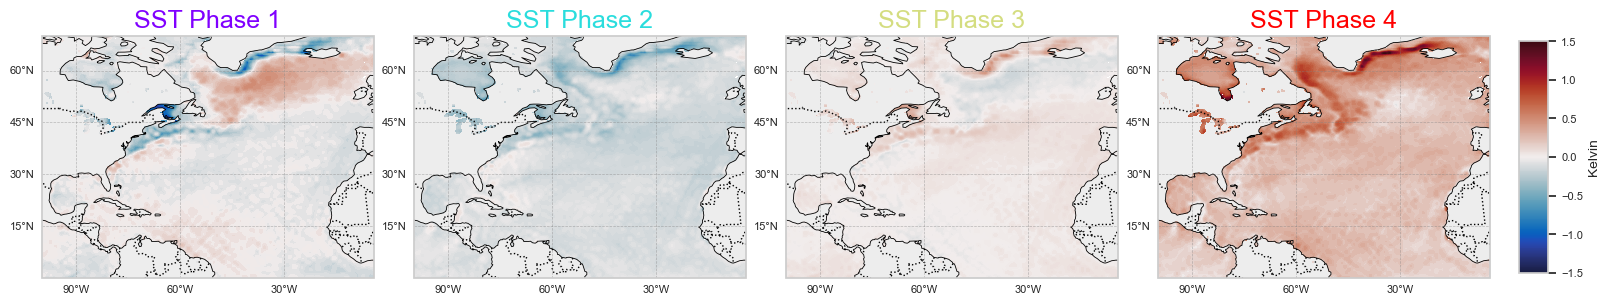

In [19]:
# --- Plot the RCs with the maps ---

pltmssa.plot_RCs_phases(
    VARs=[VAR1_RC1],
    var_names=var_names,
    expvars=[expvar_mssa[0]],
    units=units_list,
    lats=[da.lat.values for da in var_norm],
    lons=[da.lon.values for da in var_norm],
    time_axis = time_axis,
    M=M,
    varset_name=varset_name,
    title='RC 1',
    period_name='Trend',
    saving_path=saving_path
)